# **ICC ODI Cricket World Cup Data Analysis**

Yashi Jadhav | PHY/MAT 231| Spring 2026

# **Project Background**

My final project is about the ICC ODI Cricket World Cup data from 1975-2019. Cricket is a very popular sport and is played by many countries overseas, this project will focus on the One Day International format which typically is 50 overs long, with 6 balls played per over. Over 20 countries have played in this tournament, 6 of them playing every year since its inception.  

The dataset I will be using is titled CRICKET WORLD CUP SCORES(1975-2019). It contains the scores o all the cricket matches played in the world cup sources from the ICC Website and Cricbuzz website.The selected dataset has over 1000 rows of data, describing all the matches in each world cup year, the number of runs made in the game, wickets taken and lost, who played in the match, the venue, and overall world cup winner. The dataset can be found on Kaggle.com at https://www.kaggle.com/datasets/amalab182/cricket-world-cup-scores1975-2019

# **Research Questions**

Q1 - Does the host location present an advantage to certain teams? For teams who have won more than once, do they tend to win in the same host location or is there no correlation between the two?

Q2 - Who are the teams to beat? Which teams have the lowest amount of losses and does that correlate to more overall world cup wins?

Q3 - Which venues/locations had the best pitch? How do runs made on each location compare to each other and is there a specific location that's most advantageous?

# **Setup**

In [2]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import geopandas as gpd
import geodatasets
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
import math
import datetime
import sqlite3

# **ICC Cricket ODI World Cup 1975-2019 Dataset**

In [3]:
cricket = pd.read_csv('cricketworldcup.csv')
cricketold = pd.read_csv('cricketworldcupold.csv')

conn = sqlite3.connect(':memory:')
cricket.to_sql('cricket', conn, index=False)
cricketold.to_sql('cricketold', conn, index=False)

print(f"cricket table: {len(cricket)} rows, columns: {list(cricket.columns)}")
print(f"old cricket table: {len(cricketold)} rows, columns: {list(cricket.columns)}")

cricket table: 873 rows, columns: ['YEAR', 'TEAM', 'RUNS_SCORED', 'WICKETS_LOST', 'WICKETS_TAKEN', 'AGAINST', 'WINNER', 'VENUE', 'HOST_COUNTRY', 'CHAMPION']
old cricket table: 906 rows, columns: ['YEAR', 'TEAM', 'RUNS_SCORED', 'WICKETS_LOST', 'WICKETS_TAKEN', 'AGAINST', 'WINNER', 'VENUE', 'HOST_COUNTRY', 'CHAMPION']


## Column Header Descriptions

- Year - Year of the World Cup
- Team - Playing Team
- Runs Scored - Runs scored by the team
- Wickets Lost - Wickets lost while batting
- Wickets Taken - Wickets taken while bowling
- Against - Opposing Team
- Winner - Winner of the current match
- Venue - Location of the match
- Champion - Winner of the tournament

## Cleaning the Data

The dataset found on Kaggle was cleaned and filtered to become usable for this project. First, any extra rows were deleted to prevent errored values when sorting the values into a tables. Next, the "RESULT" column was changed into "WINNER", changing the value to the name of the winner of that match rather than the result "WIN" or "LOST" applying to the respective team. The last column was subsequently renamed "CHAMPION" as it desribes the overall champion of the tournament for the year in which that match was played.

Additionally, as many matches were canceled or abandoned due to weather, there were some matches that had no result. In the dataset they were marked with "NR" in all of the columns. To make the sorting process easier, I removed all of the NR games and focused only on games that were played.

## Initial Insights

Using basic functions like mean and sum we can look at some initial results from our dataset. Any columns with 

In [4]:
result = pd.read_sql_query("""
    SELECT AVG(RUNS_SCORED) as avg_runs_scored, SUM(RUNS_SCORED) as sum_runs_scored, MIN(RUNS_SCORED) as min_runs_scored, MAX(RUNS_SCORED) as MAX_runs_scored, AVG(WICKETS_LOST) as avg_wickets_lost, AVG(WICKETS_TAKEN) as avg_wickets_taken
    FROM cricket
""", conn)
result.head()


,avg_runs_scored,sum_runs_scored,min_runs_scored,MAX_runs_scored,avg_wickets_lost,avg_wickets_taken
0,219.07331,191251,36,417,7.24055,7.235968


From our results, we can see that on average each game is around 219, with the minimum being 36 and maximum being 417. Additionally we can see that the average wickets lost was around 7 while the average wickets taken was also around 7.

# **Question 1**

### Does the host location present an advantage to certain teams? For teams who have won more than once, do they tend to win in the same host location or is there no correlation between the two?

In [5]:
df = pd.read_sql_query("""
    SELECT YEAR, TEAM,RUNS_SCORED, WICKETS_LOST, WICKETS_TAKEN, AGAINST, WINNER, VENUE, CHAMPION 
    FROM cricket
""", conn)

df.head()

#wins per team
team_wins = df[df['TEAM'] == df['WINNER']].groupby('TEAM').size().sort_values(ascending=False)

#wins per venue
venue_wins = df[df['TEAM'] == df['WINNER']].groupby('VENUE').size().sort_values(ascending=False)

#team performance vs venue
team_venue_wins = df[df['TEAM'] == df['WINNER']].groupby(['TEAM', 'VENUE']).size().unstack(fill_value=0)

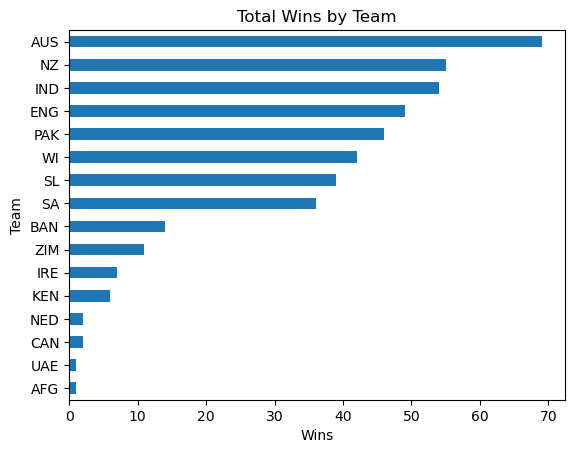

In [6]:
team_wins.sort_values().plot(kind='barh')

plt.xlabel("Wins")
plt.ylabel("Team")
plt.title("Total Wins by Team")
plt.show()

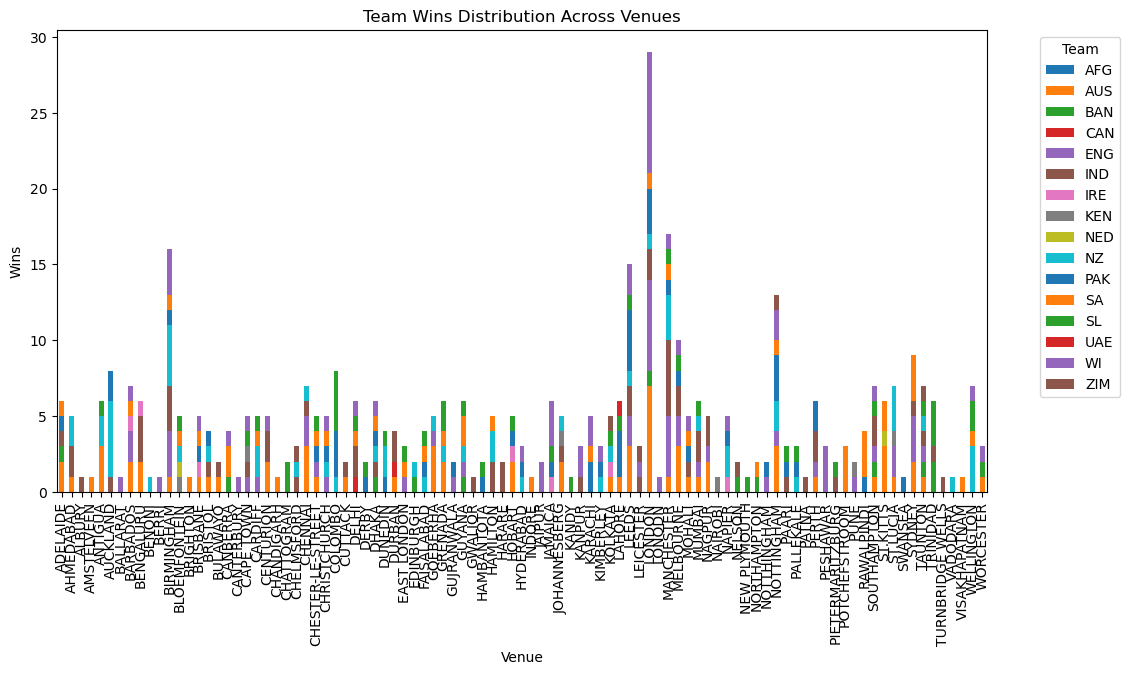

In [7]:
team_venue_wins.T.plot(kind='bar', stacked=True, figsize=(12,6))

plt.xlabel("Venue")
plt.ylabel("Wins")
plt.title("Team Wins Distribution Across Venues")
plt.legend(title="Team", bbox_to_anchor=(1.05, 1))
plt.show()

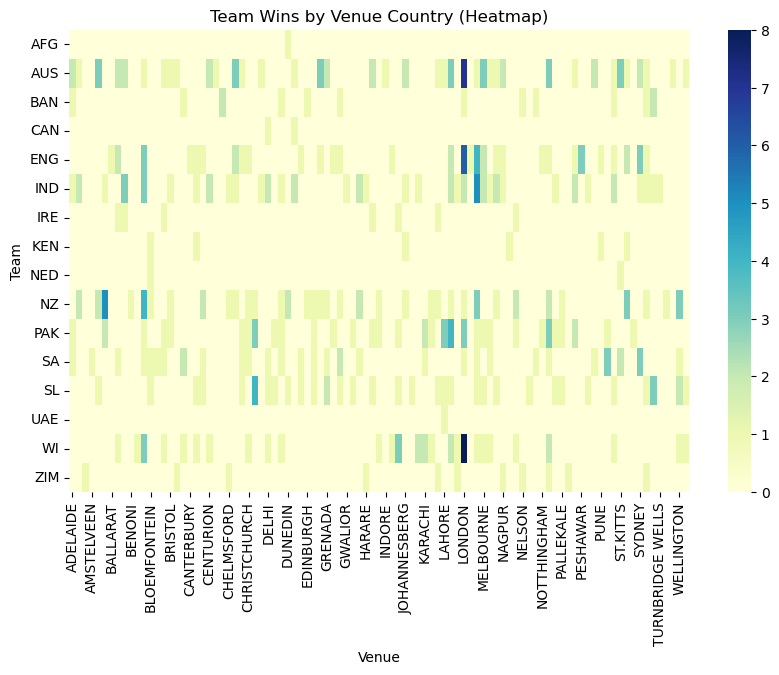

In [8]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(team_venue_wins, cmap="YlGnBu")

plt.title("Team Wins by Venue Country (Heatmap)")
plt.xlabel("Venue")
plt.ylabel("Team")
plt.show()

# **Question 2**

### Who are the teams to beat? Which teams have the lowest amount of losses and does that correlate to more overall world cup wins?

In [9]:
#gathering how many matches each country has played in 
result = pd.read_sql_query("""
    SELECT TEAM, COUNT(TEAM) as matches_played
    FROM cricketold
    GROUP BY TEAM
""", conn)

#gathering how many matches each country has won
result2 = pd.read_sql_query("""
    SELECT TEAM, COUNT(TEAM) as matches_won
    FROM cricketold
    WHERE RESULT = "WON"
    GROUP BY TEAM
""", conn)

#create a dataframe that combines the two tables(matches_ won and matches_played), replace NaN with 0 for any teams that have never won
combo = result.join(result2.set_index("TEAM"), on="TEAM", validate="m:1")
fillcombo = combo.fillna(0)

#creating a new column in the dataframe that calculates the win percentage of each team
fillcombo['win_percentage'] = (fillcombo['matches_won']/fillcombo['matches_played']) *100

#rounding out each column to 1 decimal place or less
roundcombo = fillcombo.round(decimals=1)

#gathering which country has won the cup in each year
cupwins = pd.read_sql_query("""
    SELECT YEAR, TEAM, WINNER
    FROM cricketold
    GROUP BY YEAR
""", conn)

#I manually counted the number of cups each team has won based on the 'cupwins' dataframe and inserted that information as an additional row
roundcombo.insert(4, "cupwins", [0, 5, 0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 2, 0])

#completed dataframe displaying all the data I need to plot.
print(roundcombo)



   TEAM  matches_played  matches_won  win_percentage  cupwins
0   AFG              15          1.0             6.7        0
1   AUS              96         69.0            71.9        5
2   BAN              42         14.0            33.3        0
3   BER               3          0.0             0.0        0
4   CAN              18          2.0            11.1        0
5    EA               3          0.0             0.0        0
6   ENG              84         49.0            58.3        1
7   IND              85         54.0            63.5        2
8   IRE              21          7.0            33.3        0
9   KEN              29          7.0            24.1        0
10  NAM               6          0.0             0.0        0
11  NED              20          2.0            10.0        0
12   NZ              90         54.0            60.0        0
13  PAK              80         46.0            57.5        1
14   SA              64         36.0            56.2        0
15  SCO 

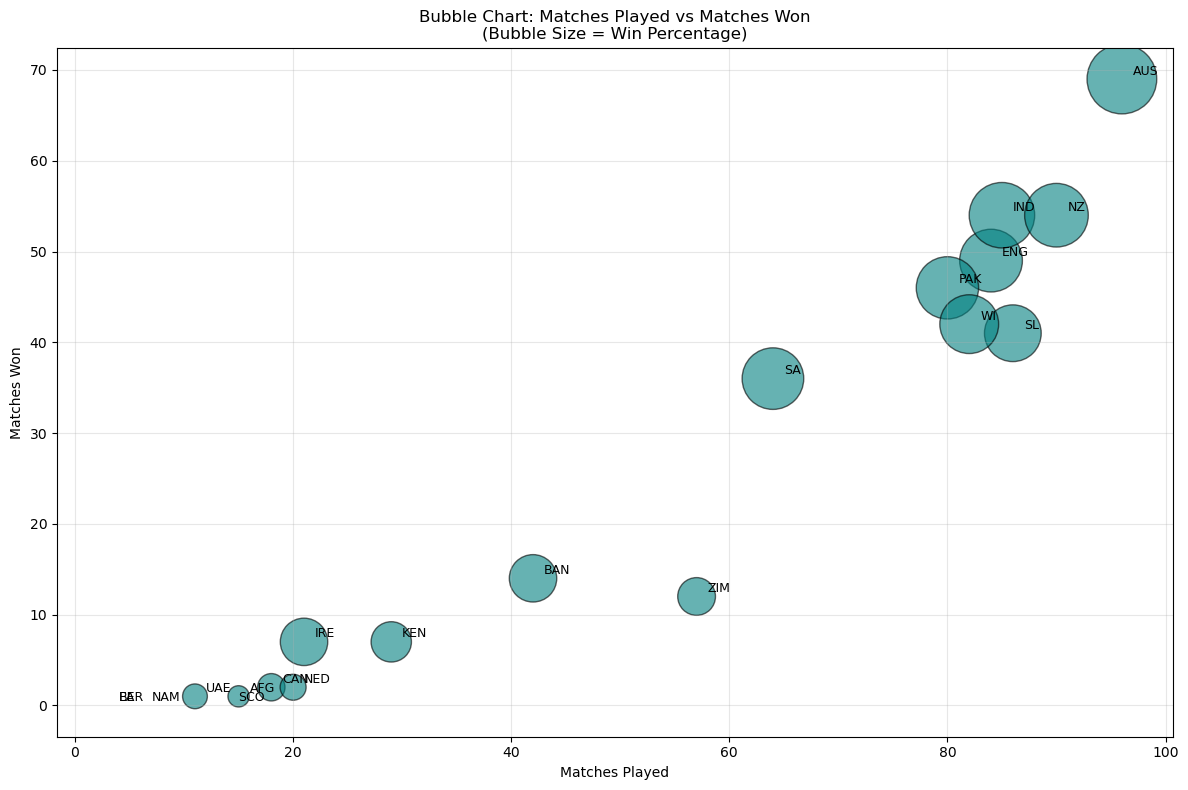

In [10]:
# show matches_played vs. matches_won 


plt.figure(figsize=(12,8))

# bubble chart
plt.scatter(
    roundcombo['matches_played'],
    roundcombo['matches_won'],
    c='teal',
    s=roundcombo['win_percentage']*35,   
    alpha=0.6,
    edgecolors='black'
)

# labels
for i, row in roundcombo.iterrows():
    plt.text(
        row['matches_played'] + 1,
        row['matches_won'] + 0.5,
        row['TEAM'],
        fontsize=9
    )

plt.xlabel('Matches Played')
plt.ylabel('Matches Won')
plt.title('Bubble Chart: Matches Played vs Matches Won\n(Bubble Size = Win Percentage)')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



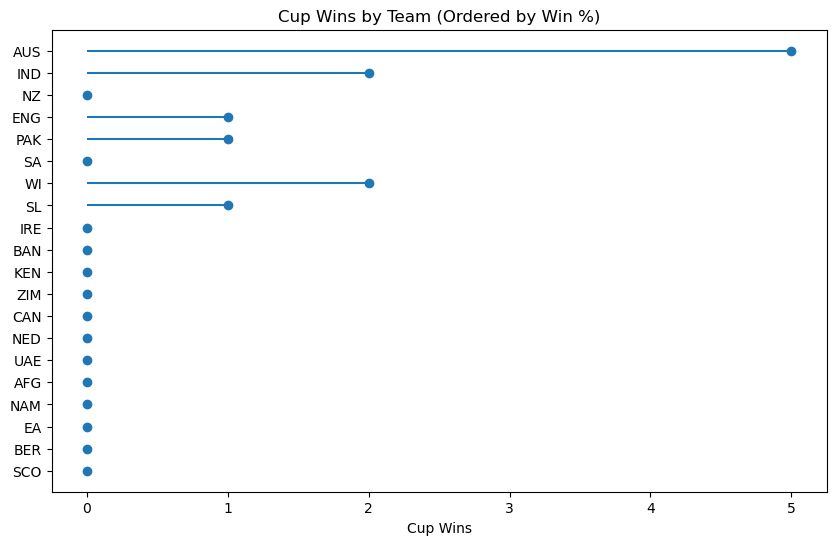

In [11]:
df = roundcombo.sort_values('win_percentage')

plt.figure(figsize=(10,6))

plt.hlines(y=df['TEAM'], xmin=0, xmax=df['cupwins'])
plt.plot(df['cupwins'], df['TEAM'], "o")

plt.xlabel("Cup Wins")
plt.title("Cup Wins by Team (Ordered by Win %)")

plt.show()


# **Question 3**

### Which venues/locations had the best pitch? How do runs made on each location compare to each other and is there a specific location that's most advantageous?

In [12]:
# filtering for 2019 world cup data only
wc2019 = cricket[cricket['YEAR'] == 2019]

venue_summary = pd.read_sql_query("""
SELECT 
    VENUE,
    COUNT(*) AS innings_played,
    ROUND(AVG(RUNS_SCORED),2) AS avg_runs_scored,
    SUM(RUNS_SCORED) AS total_runs_scored,
    ROUND(AVG(WICKETS_LOST),2) AS avg_wickets_lost,
    ROUND(AVG(WICKETS_TAKEN),2) AS avg_wickets_taken
FROM cricket
WHERE YEAR = 2019
GROUP BY VENUE
ORDER BY avg_runs_scored DESC
""", conn)

print(venue_summary)

               VENUE  innings_played  avg_runs_scored  total_runs_scored  \
0         MANCHESTER              12           273.33               3280   
1         NOTTINGHAM               8           271.25               2170   
2             LONDON              20           269.45               5389   
3         BIRMINGHAM              10           265.60               2656   
4            TAUNTON               6           260.17               1561   
5  CHESTER-LE-STREET               6           258.83               1553   
6              LEEDS               8           253.63               2029   
7        SOUTHAMPTON               8           224.88               1799   
8            BRISTOL               2           208.00                416   
9            CARDIFF               8           193.50               1548   

   avg_wickets_lost  avg_wickets_taken  
0              7.83               7.83  
1              7.38               8.13  
2              8.55               8.55  

In [13]:
top_runs = pd.read_sql_query("""
SELECT 
    VENUE,
    ROUND(AVG(RUNS_SCORED),2) AS avg_runs
FROM cricket
WHERE YEAR = 2019
GROUP BY VENUE
ORDER BY avg_runs DESC
LIMIT 5
""", conn)

print(top_runs)

        VENUE  avg_runs
0  MANCHESTER    273.33
1  NOTTINGHAM    271.25
2      LONDON    269.45
3  BIRMINGHAM    265.60
4     TAUNTON    260.17


In [14]:
bowling_pitch = pd.read_sql_query("""
SELECT 
    VENUE,
    ROUND(AVG(RUNS_SCORED),2) AS avg_runs,
    ROUND(AVG(WICKETS_LOST),2) AS avg_wickets_lost
FROM cricket
WHERE YEAR = 2019
GROUP BY VENUE
ORDER BY avg_runs ASC
""", conn)

print(bowling_pitch)


               VENUE  avg_runs  avg_wickets_lost
0            CARDIFF    193.50              7.13
1            BRISTOL    208.00              6.50
2        SOUTHAMPTON    224.88              7.50
3              LEEDS    253.63              7.63
4  CHESTER-LE-STREET    258.83              7.33
5            TAUNTON    260.17              7.33
6         BIRMINGHAM    265.60              6.50
7             LONDON    269.45              8.55
8         NOTTINGHAM    271.25              7.38
9         MANCHESTER    273.33              7.83


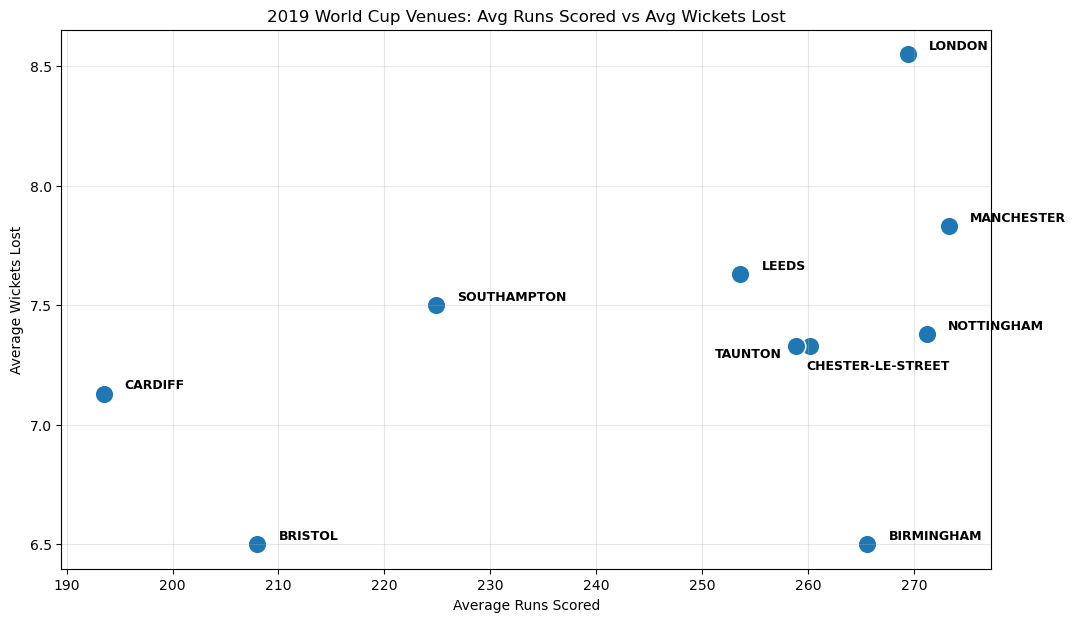

In [15]:
plt.figure(figsize=(12,7))

# made a scatterplot using seaborn
sns.scatterplot(
    data=venue_summary,
    x='avg_runs_scored',
    y='avg_wickets_lost',
    s=180
)

# I needed to offset the data labels for these two venues because they were too close and overlapped
offsets = {
    "CHESTER-LE-STREET": (1, -.1),   
    "TAUNTON": (-9, -0.05)           
}

# adds the data labels for each venue using an iterative loop
for i in range(len(venue_summary)):
    
    venue = venue_summary['VENUE'][i]
    x = venue_summary['avg_runs_scored'][i]
    y = venue_summary['avg_wickets_lost'][i]

    dx, dy = offsets.get(venue, (2, 0.02))

    plt.text(
        x + dx,
        y + dy,
        venue,
        fontsize=9,
        fontweight='bold'
    )

# titles and axis labels
plt.title("2019 World Cup Venues: Avg Runs Scored vs Avg Wickets Lost")
plt.xlabel("Average Runs Scored")
plt.ylabel("Average Wickets Lost")
plt.grid(True, alpha=0.3)
plt.show()

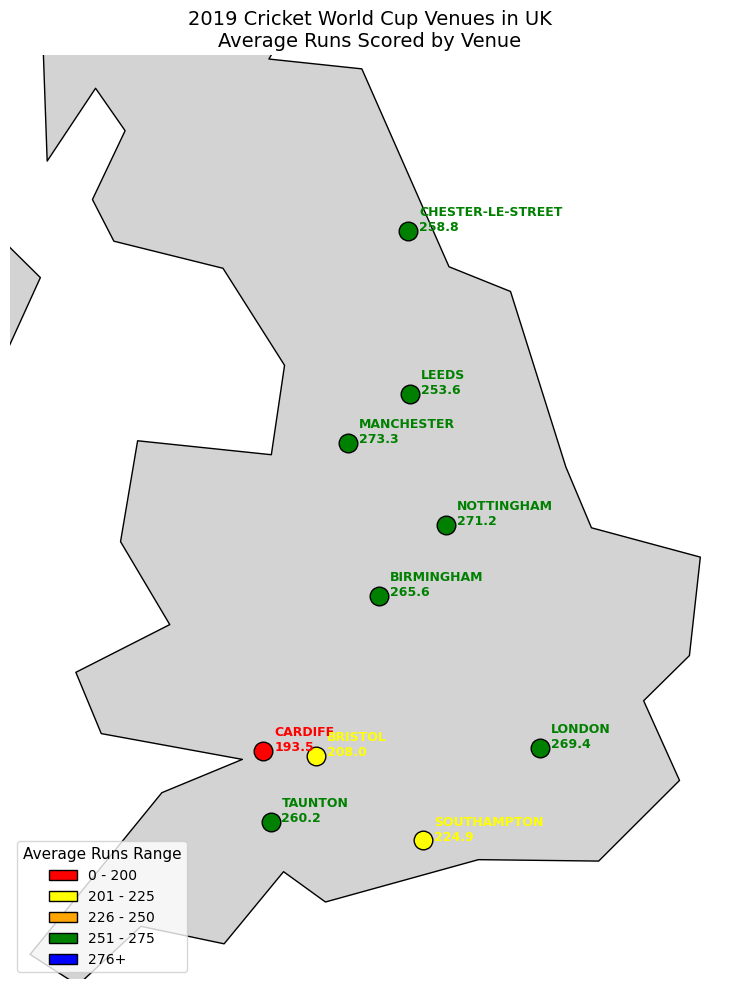

In [16]:

# select only 2019 world cup data played in the UK
wc2019 = cricket[cricket["YEAR"] == 2019]

# Average runs by venue
venue_runs = wc2019.groupby("VENUE")["RUNS_SCORED"].mean().reset_index()
venue_runs.columns = ["VENUE", "AVG_RUNS"]

#establishing coordinates for the venues
coords = {
    "LONDON": (-0.10, 51.50),
    "LEEDS": (-1.55, 53.80),
    "NOTTINGHAM": (-1.15, 52.95),
    "MANCHESTER": (-2.24, 53.48),
    "BIRMINGHAM": (-1.89, 52.49),
    "CARDIFF": (-3.18, 51.48),
    "BRISTOL": (-2.59, 51.45),
    "SOUTHAMPTON": (-1.40, 50.90),
    "TAUNTON": (-3.10, 51.02),
    "CHESTER-LE-STREET": (-1.57, 54.86)
}

venue_runs["lon"] = venue_runs["VENUE"].map(lambda x: coords[x][0])
venue_runs["lat"] = venue_runs["VENUE"].map(lambda x: coords[x][1])

# assign colors to varying ranged of runs scored
def get_color(runs):
    if runs <= 200:
        return "red"
    elif runs <= 225:
        return "yellow"
    elif runs <= 250:
        return "orange"
    elif runs <= 275:
        return "green"
    else:
        return "blue"

venue_runs["color"] = venue_runs["AVG_RUNS"].apply(get_color)

# make a geodataframe
gdf = gpd.GeoDataFrame(
    venue_runs,
    geometry=gpd.points_from_xy(venue_runs.lon, venue_runs.lat),
    crs="EPSG:4326"
)

# load in the world map and focus it on the UK
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)
uk = world[world["NAME"] == "United Kingdom"]


fig, ax = plt.subplots(figsize=(10, 12))

uk.plot(ax=ax, color="lightgray", edgecolor="black")

# plot points and labels
for idx, row in gdf.iterrows():
    ax.scatter(
        row.geometry.x,
        row.geometry.y,
        color=row["color"],
        s=180,
        edgecolor="black"
    )

    ax.text(
        row.geometry.x + 0.12,
        row.geometry.y,
        f'{row["VENUE"]}\n{row["AVG_RUNS"]:.1f}',
        fontsize=9,
        fontweight="bold",
        color=row["color"]
    )


legend_elements = [
    Patch(facecolor='red', edgecolor='black', label='0 - 200'),
    Patch(facecolor='yellow', edgecolor='black', label='201 - 225'),
    Patch(facecolor='orange', edgecolor='black', label='226 - 250'),
    Patch(facecolor='green', edgecolor='black', label='251 - 275'),
    Patch(facecolor='blue', edgecolor='black', label='276+')
]

ax.legend(
    handles=legend_elements,
    title="Average Runs Range",
    loc="lower left",
    fontsize=10,
    title_fontsize=11
)


plt.title("2019 Cricket World Cup Venues in UK\nAverage Runs Scored by Venue", fontsize=14)
plt.xlim(-6, 2)
plt.ylim(50, 56)
ax.set_axis_off()

plt.show()

## **REFLECTIONS**

### Question 1

Question 1 provides insight into how scoring varies across different venues and host countries in the World Cup dataset. By examining the average runs scored at each venue, it becomes clear that while some locations tend to produce higher scoring matches, these venues are distributed across multiple host countries rather than concentrated within a single region. This suggests that no single host country consistently produces the highest scoring environments.

Although certain venues rank higher in terms of average runs, the differences between them are not extreme enough to indicate a strong or systematic advantage tied to location. Additionally, when aggregating the data at the host country level, the averages remain relatively balanced, reinforcing the idea that scoring conditions are fairly consistent across countries.

The results suggest that while venue specific factors (such as pitch conditions) may influence match scoring to some extent, there is no clear evidence that host country alone significantly impacts scoring outcomes. This indicates that variations in runs scored are more likely due to individual match conditions or team performance rather than a consistent geographical advantage.

### Question 2

In examining team performance and dominance, the results show that certain teams consistently achieve more wins than others, reinforcing the idea that team strength and skill level are the primary drivers of success. While some teams have higher win counts and appear more dominant historically, this success does not appear to be tied to specific venues or host countries.

Additionally, when considering teams that have won multiple times, there is no clear pattern showing that they repeatedly win in the same locations. Instead, their victories are spread across different venues, further supporting the conclusion that there is little correlation between repeated success and specific host locations. This suggests that strong teams are adaptable and capable of performing well under varying conditions.

### Question 3

The results from Question 3 show that venue conditions had a noticeable impact on scoring patterns during the 2019 Cricket World Cup. Some grounds produced much higher average run totals, suggesting flatter pitches, shorter boundaries, or batting friendly conditions, while other venues had lower averages and more wickets lost, indicating stronger assistance for bowlers. This demonstrates that match location can significantly influence team strategy, such as whether captains prefer to bat first or rely more heavily on pace and spin attacks.

The scatter plot also highlights that higher scoring venues did not always correspond with fewer wickets lost. In several cases, teams still lost wickets while maintaining strong totals, showing that aggressive batting approaches often came with added risk. Venues like Taunton and Chester-le-Street appearing differently from others suggest that each ground had unique playing characteristics rather than following one consistent trend.

Overall, the analysis confirms that venue specific factors are an important part of cricket performance analytics. Teams that adapt better to pitch behavior, weather, and ground dimensions are more likely to succeed in tournament play. These findings help explain why understanding historical venue data is valuable for match preparation and predictive analysis.